# TensorFlow를 활용한 로지스틱 회귀 실습

이 노트북에서는 TensorFlow를 사용하여 간단한 로지스틱 회귀문제를 풀어봅니다.
여기서는 iris 데이터셋을 사용하여 꽃의 종류를 분류하는 예제를 다룹니다.

## 주요 단계
1. 데이터 불러오기 및 전처리
2. 모델 정의 (Dense Layer)
3. 손실 함수 및 최적화 방법 설정
4. 학습 진행 및 시각화


In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,614 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126435 files and dire

In [2]:
# matplotlib 폰트 깨짐 현상 해결
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False # Enable negative sign for Korean fonts

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
print(tf.__version__)

2.19.0


## 1. 데이터 불러오기 및 전처리

In [4]:
# ----------------------
# 1. 데이터 불러오기
# ----------------------
iris = load_iris()
X = iris.data[:, :2]  # 꽃받침 길이, 꽃받침 너비 (2개 feature만 사용해서 시각화 쉽게)
y = (iris.target == 0).astype(np.float32)  # Setosa = 1, Others = 0

print("X shape:", X.shape, "y shape:", y.shape)

# train/test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 표준화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X shape: (150, 2) y shape: (150,)


## 2. 모델 정의

In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

## 3. 모델 컴파일
- 손실 함수: MSE (Mean Squared Error)
- 최적화 방법: SGD (Stochastic Gradient Descent)

In [7]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              loss="binary_crossentropy",
              metrics=["accuracy"])

## 4. 모델 학습

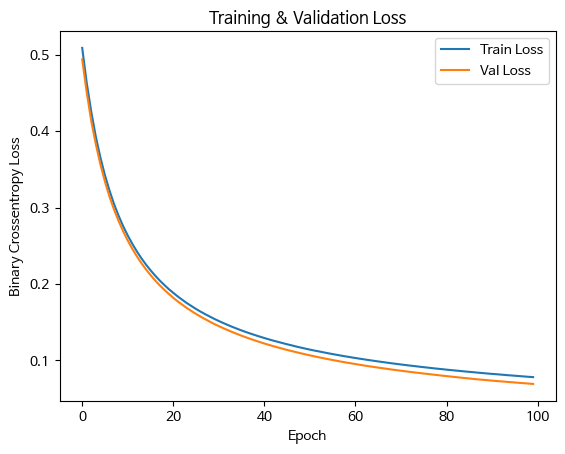

In [8]:
history = model.fit(X_train, y_train,
                    epochs=100,
                    validation_data=(X_test, y_test),
                    verbose=0)

# ----------------------
# 5. 학습 곡선 확인
# ----------------------
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()
plt.title("Training & Validation Loss")
plt.show()

## 5. 결과 확인

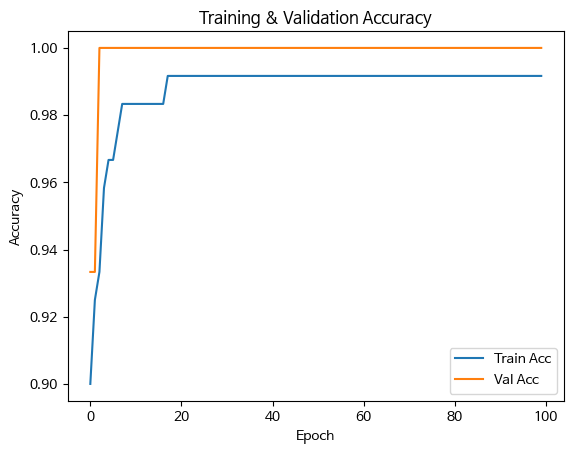

테스트 정확도: 1.000


In [9]:
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training & Validation Accuracy")
plt.show()

# ----------------------
# 6. 모델 평가
# ----------------------
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"테스트 정확도: {acc:.3f}")

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


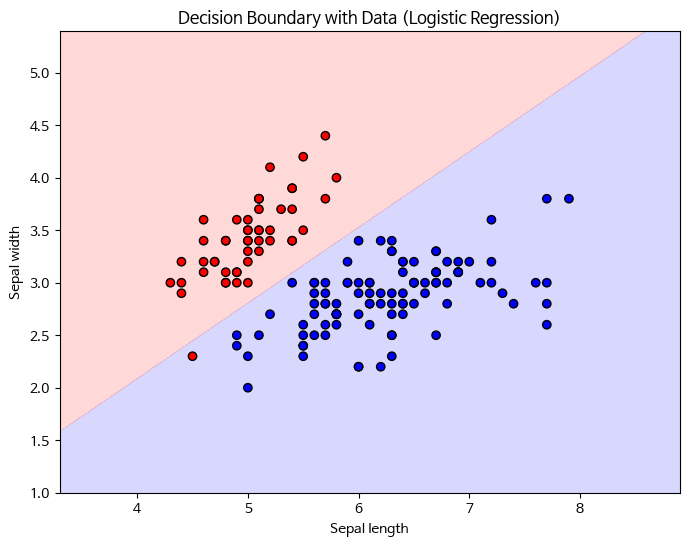

In [10]:
# ----------------------
# 결정 경계 + 전체 데이터 시각화
# ----------------------
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid = np.c_[xx.ravel(), yy.ravel()]
grid = scaler.transform(grid)
probs = model.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8, 6))

# 결정 경계 (배경 색)
plt.contourf(xx, yy, probs, levels=[0, 0.5, 1], alpha=0.3, cmap="bwr")

# 전체 데이터 산점도 (훈련+테스트)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")

plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("Decision Boundary with Data (Logistic Regression)")
plt.show()

## 생각해보기
- 로지스틱 회귀 모델과 선형 회귀 모델의 차이는?
    - 선형 회귀
      - 목적 : 연속적인 수치 예측
      - 출력범위 : 제한 없음
      - 활성화 함수 : 없음 (선형 함수)
      - 수식 : y = wx + b
      - 손실 함수 : MSE (Mean Squared Error)
      - 예시 : 주택 가격 예측, 온도 예측

    - 로지스틱 회귀
      - 목적 : 범주형 분류
      - 출력 범위 : 0 ~ 1 (확률값)
      - 활성화 함수: 시그모이드 함수
      - 수식 : y = sigmoid(wx + b) = 1/(1+e^(-wx-b))
      - 예시 : 스팸 메일 분류, 질병 진단

    - 핵심 차이점
      - 출력 해석 : 선형회귀는 실제 값, 로지스틱회귀는 확률
      - 결정 경계 : 로지스틱회귀는 0.5를 기준으로 분류
      - 함수 형태 : 선형회귀는 직선, 로지스틱회귀는 S자 곡선

- Learning Rate(학습률)의 역할은 무엇인가요?
    - 학습률이란?
      - 역할 : 가중치 업데이트 시 얼마나 큰 폭으로 움직일지 결정하는 하이퍼파라미터
      - 수식 : w_new = w_old - learning_rate x gradient
      - 비유 : 산에서 내려올 때의 발걸음 크기

    - 학습률의 영향
     - 적절한 학습률 : 안정적이고 효율적인 최적점 도달
     - 학습 속도 조절 : 너무 빠르지도 느리지도 않은 최적 학습
     - 수렴성 결정 : 모델이 최적해에 도달할 수 있는지 좌우

- 너무 크거나 너무 작은 학습률을 사용하면 어떤 일이 발생하나?
  - 학습률이 너무 클 때
    - 문제점
      - 발산 : 손실이 계속 증가하여 학습 실패
      - 진동: 최적점 주변에서 왔다 갔다 하며 수렴 못함
      - Gradient Explosion : 기울기가 폭발적으로 커짐
      - 불안정한 학습 : 손실 곡선이 들쭉날쭉함
  - 결과
    - 모델이 전혀 학습되지 않음
    - 정확도가 개선되지 않거나 오히려 악화
    - NaN 값 발생 가능성
  
  - 학습률이 너무 작을 때
    - 문제점
      - 매우 느린 수렴 : 최적점에 도달하는데 과도한 시간 소요
      - Local Minima 함정 : 지역 최적점에서 벗어나지 못함
      - 학습 정체 : 손실이 거의 감소하지 않음
      - 조기 포기 : 실제로는 더 학습이 필요한데 멈춤
    - 결과
      - 충분한 성능에 도달하지 못함
      - 학습 시간 과다 소요
      - 컴퓨팅 자원 낭비

  - 적절한 학습률 찾기
    - 일반적인 범위 : 0.01 ~ 0.1
    - Learning Rage Scheduling : 학습 과정에서 점진적 감소
    - 적응적 최적화 : Adam, RMSprop 등 자동 조절 알고리즘
    - 실험적 접근 : 여러 값을 시도해보며 최적값 탐색